# Looking at the historical US market returns

## Imports

In [19]:
import pandas as pd
import math
import matplotlib.pyplot as pyplot
import datetime as dt

## Data

### Shiller's historical S&P 500 data

Importing the formatted data.

In [20]:
csv_path = '../../data/shiller/shiller_sp500_pandas_formatted.csv'
df = pd.read_csv(csv_path, parse_dates=['Date'])

## Dividend re-invested Compound Annual Growth Rate (CAGR)

### Reinvesting dividends

Suppose we have $s$ shares of an S&P 500 index fund, priced at $p$ dollars per share.  If the fund issues a dividend of $d$ dollars per share, we arrive at a total dividend payout of $D = sd$ dollars.  We can reinvest this payout back into the fund to purchase $\Delta s = D/p = sd/p$ new shares, resulting in $s_d$ total shares, where  
$s_d = s + \Delta s = s\left( 1 + d/p \right)$.

We didn't rely on any history of $s$ for this calculation, so the case where the initial shares $s$ already included a previous dividend payout follows automatically.  Indexing the first payout with `1` and the latter payout with `2`, we would find that the share count has evolved from a base value $s$ according to  
$s_{d,2} = s_{d,1}\left( 1 + d_2/p_2 \right) = s\left( 1 + d_1 / p_1 \right)\left( 1 + d_2/p_2 \right)$.  

More generally, the current number of shares from reinvesting dividends can be determined from the initial number of shares $s_0$ combined with the historical dividend payout per share $d$ and the price per share $p$ at the time of reinvestment.  
$s = s_0\prod_i\left( 1 + d_i/p_i \right)$

### Dividends in Shiller's data

Per [Shiller's website description](https://shillerdata.com/), the monthly dividend data are really linear interpolations of longer timeframes.  E.g., the dividends since 1926 are interpolated from S&P quarterly results on dividend payouts.  What's _not stated_ directly on the data website is that the `Dividend` column apparently represents the trailing 12-month dividend total payout for the S&P 500.  The full explanation can be found [on Shiller's Yale page](http://www.econ.yale.edu/~shiller/data/chapt26.html) discussing chapter 26 of his _Market Volatility_ text.  I only really stumbled onto this definition after first seeing it on [multpl](https://www.multpl.com/s-p-500-dividend) and doing some Google hunting for Shiller's specific description.

Currently, I'm simply dividing the `Dividend` column value by 12 to approximate a monthly dividend payout used to calculate monthly reinvestment.  This has the effect of smoothing out the dividend reinvestments, in a kind of dollar-cost-averaging of dividend payouts.  On some level, this might be reasonable for an analysis that only tracks the S&P 500 on a monthly basis, but it's certain to introduce some (hopefully sub-leading) error.

### Compound Annual Growth Rate (CAGR) with dividends reinvested

To calculate the Compound Annual Growth Rate (CAGR) over a period of time using the Shiller data, we can apply the dividend reinvestment formulas with the additional approximation that the dividend payout per share is  
$d_i = D_{i, 12}/12$,  
where $D_{i,12}$ is the trailing 12-month total of dividends.  If the price per share of the S&P 500 index fund is $p_0$ at some initial time, then    
$(\text{initial value}) = p_0 s_0$.  
If the price per share is $p_f$ at some later time, then  
$(\text{final value}) = p_f s_f = p_f s_0 \prod_i\left( 1 + d_i/p_i \right) =
p_f s_0 \prod_i \left( 1 + D_i/12 p_i \right)$.  
The total growth ratio $G$ is given by the ratio  
$G := \frac{\text{(final value)}}{\text{(initial value)}}
= \frac{p_f}{p_0}\prod_i \left( 1 + D_i/12 p_i \right)$.  
The growth ratio can be related to an annually-compounded growth rate $r$,  
$G = \left( 1 + r \right)^{t_f - t_0}$,  
where $t_f - t_0$ is the period between initial and final times, in _years_.  Here, I'm avoiding the issue of fractional differences in years and simply allowing for fractional annual compounding, with the assumption that I will typically consider the CAGR over many years. The annually-compounded growth rate $r$ between periods of time in the Shiller data, with dividends reinvested, can be calculated via  
$r = G^{1/(t_f - t_0)} - 1
= \left[\frac{p_f}{p_0}\prod_i \left( 1 + D_i/12 p_i \right) \right]^{1/(t_f-t_0)} - 1$  

In [21]:
def cagr(initial: dt.datetime, final: dt.datetime, dividends: bool=True) -> float:
    """
    Calculates the Compound Annual Growth Rate (CAGR) between the final and initial periods,
    inclusive, where dividends are reinvested by default.
    - initial: The datetime.datetime of the period to start the CAGR analysis
    - final: The datetime.datetime of the period to end the CAGR analysis.
    - dividends: [default True] A boolean flag to determine whether to consider reinvested divdidends in the growth over the period.

    Example: cagr(2014.01, 2024.03) calculates the CAGR between January 2014 and  March 2024, with dividends reinvested.
    """

    rows = df[(df["Date"] >= initial) & (df["Date"] <= final)]
    return df_cagr(rows, dividends)

def df_cagr(rows: pd.DataFrame, dividends: bool) -> float:
    """
    Calculates the CAGR for the input dataframe, where the format is expected to be the same as
    extracted from the Shiller data.
    """

    initial_row = rows.iloc[0]
    final_row = rows.iloc[-1]
    
    dividend_factor = calculate_dividend_factor(rows, dividends)

    initial = initial_row["S&P"]
    final = dividend_factor * final_row["S&P"]
    period = (final_row["Date"] - initial_row["Date"]).days / 365.25  # CAUTION: wrong around 1900

    # Yearly compounding, ignoring issues with fractional year contributions
    return math.pow(final / initial, 1 / period) - 1

def calculate_dividend_factor(rows: pd.DataFrame, dividends: bool) -> float:
    """
    Calculates the additional growth factor due to the increased shares from dividend reinvestment.
    """

    if not dividends:
        return 1

    # The "Dividend" column is the total dividend return of the S&P over the last 12 months.
    # This calculation approximates the current month's dividends by 1/12th of this rolling average.
    dividend_factor = (1 + rows["Dividend"] / 12 / rows["S&P"]).product()
    return dividend_factor

#### Comparisons to online resources

The CAGR formulas here  are compared to two online resources (listed below) as a sanity check.  The calculations essentially agree with dqydj's values and are within a few percent of moneychimp's values.

- [Don't Quit Your Day Job (dqydj)](https://dqydj.com/sp-500-return-calculator/)
- [moneychimp](http://www.moneychimp.com/features/market_cagr.htm)  [Note: the range Jan 1st 2014 to Dec 31st 2024 is likely different than the January 2014 -> January 2025 ranges used here and on dqydj.]

In [22]:
initial_date = dt.datetime(2014, 1, 1)
final_date = dt.datetime(2025, 1, 1)
print("January 2014 to January 2025 comparisons\n\n")

with_dividends = cagr(initial_date, final_date)
moneychimp_dividend = 0.1319
dqydj_dividend = 0.13403
print("Calculated CAGR with dividends:", with_dividends)
print("Relative to moneychimp:", with_dividends / moneychimp_dividend)
print("Relative to dqydj:", with_dividends / dqydj_dividend)

print("\n\n")

without_dividends = cagr(initial_date, final_date, dividends=False)
moneychimp_without = 0.1111
dqydj_without = 0.11407
print("Calculated CAGR without dividends:", without_dividends)
print("Relative to moneychimp:", without_dividends / moneychimp_without)
print("Relative to dqydj:", without_dividends / dqydj_without)

January 2014 to January 2025 comparisons


Calculated CAGR with dividends: 0.13418460971092916
Relative to moneychimp: 1.017320771121525
Relative to dqydj: 1.0011535455564362



Calculated CAGR without dividends: 0.11406124063333345
Relative to moneychimp: 1.0266538310831093
Relative to dqydj: 0.9999232106016783


## Historical long term CAGR in Shiller's data

In [23]:
period = dt.timedelta(days = 365.25 * 30)  # Poor man's leap years
start = df['Date'].iloc[-1] - period  # Remove dates outside the analysis range

historical_dates = df[df['Date'] < start]['Date']
historical_cagr = historical_dates.apply(lambda row: cagr(row, row + period))
historical_cagr_no_dividends = historical_dates.apply(lambda row: cagr(row, row + period, dividends=False))

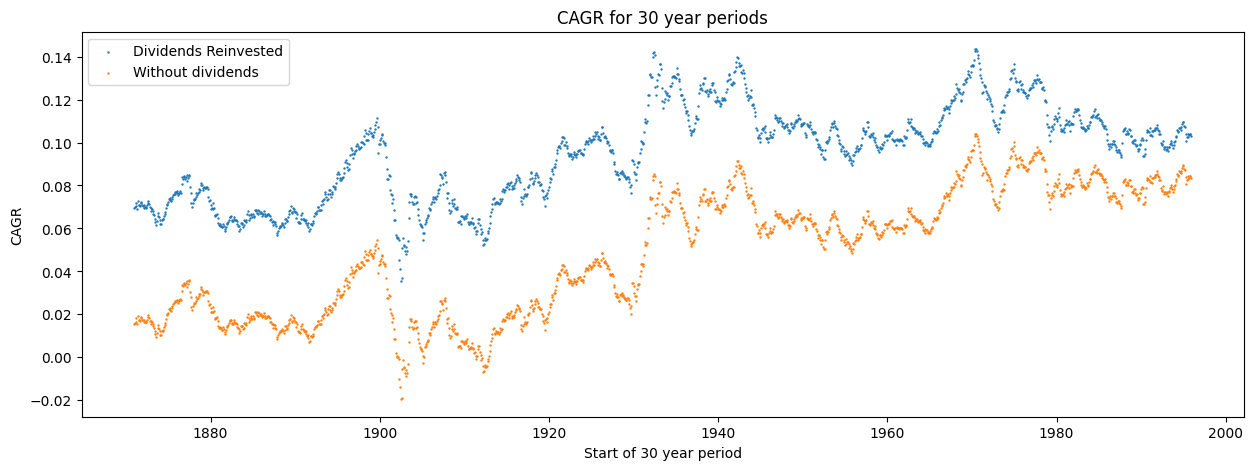

In [24]:
# Set (global) plot dimensions
pyplot.rcParams["figure.figsize"] = (15,5)

pyplot.scatter(x=historical_dates.to_list(), y=historical_cagr.to_list(), s=0.5, label='Dividends Reinvested')   
pyplot.scatter(x=historical_dates.to_list(), y=historical_cagr_no_dividends.to_list(), s=0.5, label='Without dividends')
pyplot.legend()
pyplot.xlabel('Start of 30 year period')
pyplot.ylabel('CAGR')
pyplot.title('CAGR for 30 year periods')
pyplot.show()